# 🌡️ Global Land Temperatures — Phase 3: Pipeline, Metrics & Professional Visualizations
**Big Data Analytics | Group Project — Phase 3**

**Pipeline:** Google Drive → pandas → scikit-learn Pipeline → GridSearchCV → joblib → Plotly/matplotlib  
**Algorithms:** Ridge Regression (Prediction) + K-Means Clustering  
**Deliverables:** 6 professional visualizations + full algorithm metrics + serialized model

---
## Table of Contents
1. [Setup & Drive Mount](#1)
2. [Data Loading & Preprocessing](#2)
3. [Feature Engineering](#3)
4. [Pipeline — GridSearchCV (Regression)](#4)
5. [Algorithm Metrics — Regression](#5)
6. [K-Means Pipeline & Metrics](#6)
7. [Fig 1 — Metric Dashboard](#7)
8. [Fig 2 — Residual Analysis](#8)
9. [Fig 3 — Interactive Warming Forecast (Plotly)](#9)
10. [Fig 4 — Cluster Feature Heatmap](#10)
11. [Fig 5 — Interactive 3D PCA (Plotly)](#11)
12. [Fig 6 — Interactive World Map (Plotly)](#12)
13. [Model Export & Summary](#13)

## 1. Setup & Drive Mount <a id='1'></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sklearn, pandas as pd
print(f'scikit-learn version: {sklearn.__version__}')  # log for reproducibility
print(f'pandas version:       {pd.__version__}')

FILE_PATH  = '/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv'
CLEAN_PATH = '/content/drive/MyDrive/GlobalLandTemp_cleaned.csv'
OUT        = '/content/drive/MyDrive/'

print('✅ Drive mounted. Paths set.')

Mounted at /content/drive
scikit-learn version: 1.6.1
pandas version:       2.2.2
✅ Drive mounted. Paths set.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import scipy.stats as st
import joblib, os, warnings
warnings.filterwarnings('ignore')

# install extras if needed
os.system('pip install -q pycountry plotly kaleido')
import pycountry

plt.rcParams.update({
    'figure.dpi':120,'font.family':'sans-serif',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.25,
    'axes.facecolor':'#F8FAFF','figure.facecolor':'white',
})
PALETTE = ['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED']
print('✅ All libraries loaded.')

✅ All libraries loaded.


## 2. Data Loading & Preprocessing <a id='2'></a>

In [ ]:
import os
if os.path.exists(CLEAN_PATH):
    print('Loading Phase 1 cleaned dataset...')
    df = pd.read_csv(CLEAN_PATH) # Load without parse_dates initially
    if 'dt' in df.columns: # Check if 'dt' column exists
        df.rename(columns={'dt':'Day'}, inplace=True)
    df['Day'] = pd.to_datetime(df['Day']) # Ensure 'Day' is datetime
else:
    print('Loading raw CSV (~60s)...')
    df = pd.read_csv(FILE_PATH)
    df.columns = ['dt','Avg_Temp_C','Temp_Uncertainty_C','City','Country','Latitude','Longitude']
    df['dt']    = pd.to_datetime(df['dt'])
    df['Year']  = df['dt'].dt.year
    df['Month'] = df['dt'].dt.month
    df['Decade']= (df['Year'] // 10) * 10
    df = df.dropna(subset=['Avg_Temp_C'])
    df.rename(columns={'dt':'Day'}, inplace=True)

# ensure types
if 'Year' not in df.columns:  df['Year']  = df['Day'].dt.year
if 'Month' not in df.columns: df['Month'] = df['Day'].dt.month

print(f'Shape: {df.shape[0]:,} rows  |  {df["Year"].min()}–{df["Year"].max()}')
print(f'500K requirement met: {"✅" if len(df)>=500000 else "❌"}')

Loading Phase 1 cleaned dataset...
Shape: 8,235,082 rows  |  1743–2013
500K requirement met: ✅


## 3. Feature Engineering <a id='3'></a>

In [ ]:
# Annual city-level means (for regression)
city_yr = df.groupby(['City','Country','Year'])['Avg_Temp_C'].mean().reset_index()

# City profile features (for clustering)
mean_temp   = df.groupby(['City','Country'])['Avg_Temp_C'].mean().rename('Mean_Temp')
seasonality = (df.groupby(['City','Country','Month'])['Avg_Temp_C'].mean()
               .reset_index()
               .groupby(['City','Country'])['Avg_Temp_C']
               .agg(lambda x: x.max()-x.min())
               .rename('Seasonality'))

def warming_rate(g):
    g = g[g['Year']>=1900]
    if len(g)<20: return np.nan
    return st.linregress(g['Year'], g['Avg_Temp_C'])[0]

warm_rate = city_yr.groupby(['City','Country']).apply(warming_rate).rename('Warming_Rate')

city_profiles = pd.concat([mean_temp, seasonality, warm_rate], axis=1).dropna().reset_index()
print(f'City profiles: {city_profiles.shape[0]} cities')
city_profiles.head(3)

City profiles: 3490 cities


,City,Country,Mean_Temp,Seasonality,Warming_Rate
0,A Coruña,Spain,13.147277,10.556261,0.010228
1,Aachen,Germany,8.825173,17.240664,0.010809
2,Aalborg,Denmark,7.695135,17.436224,0.009883


## 4. Pipeline — GridSearchCV (Regression) <a id='4'></a>

In [ ]:
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import PolynomialFeatures, StandardScaler
from sklearn.linear_model    import Ridge
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
import numpy as np # Import numpy for sqrt

SAMPLE_CITIES = [
    ('Paris','France'),('Mumbai','India'),('Moscow','Russia'),
    ('Lagos','Nigeria'),('Buenos Aires','Argentina'),('Sydney','Australia'),
]

regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('model',  Ridge()),
])
param_grid = {
    'poly__degree': [1, 2, 3],
    'model__alpha':  [0.01, 0.1, 1.0, 10.0, 100.0],
}

results = {}
for city, country in SAMPLE_CITIES:
    sub = city_yr[(city_yr['City']==city)&(city_yr['Country']==country)&(city_yr['Year']>=1900)].dropna()
    if len(sub)<20: continue
    X, y       = sub[['Year']], sub['Avg_Temp_C']
    train_mask = sub['Year'] < 2000
    X_tr, X_te = X[train_mask], X[~train_mask]
    y_tr, y_te = y[train_mask], y[~train_mask]

    grid = GridSearchCV(regression_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    best  = grid.best_estimator_
    y_pred= best.predict(X_te)
    cv_sc = cross_val_score(best, X, y, cv=5, scoring='r2')

    results[f'{city}, {country}'] = {
        'model':best,'X':X,'y':y,'sub':sub,'y_te':y_te,'y_pred':y_pred,
        'RMSE': round(np.sqrt(mean_squared_error(y_te,y_pred)),3), # Fixed: calculate RMSE via sqrt(MSE)
        'MAE':  round(mean_absolute_error(y_te,y_pred),3),
        'R2':   round(r2_score(y_te,y_pred),3),
        'CV_mean': round(cv_sc.mean(),3), 'CV_std': round(cv_sc.std(),3),
        'best_params': grid.best_params_,
    }

print(f'{"City":<28} {"RMSE":>7} {"MAE":>7} {"R2":>7} {"CV R2":>12} {"Best Params"}')
print('-'*80)
for k,v in results.items():
    print(f'{k:<28} {v["RMSE"]:>7.3f} {v["MAE"]:>7.3f} {v["R2"]:>7.3f}  {v["CV_mean"]:.3f}±{v["CV_std"]:.3f}  {v["best_params"]}')

City                            RMSE     MAE      R2        CV R2 Best Params
--------------------------------------------------------------------------------
Paris, France                  0.537   0.442  -0.443  -0.281±0.339  {'model__alpha': 100.0, 'poly__degree': 3}
Moscow, Russia                 0.700   0.577  -0.449  -0.257±0.654  {'model__alpha': 100.0, 'poly__degree': 3}
Lagos, Nigeria                 0.323   0.240  -1.252  -1.193±0.990  {'model__alpha': 1.0, 'poly__degree': 3}
Sydney, Australia              0.289   0.249  -0.425  -0.092±0.288  {'model__alpha': 1.0, 'poly__degree': 2}


In [ ]:
# Residuals for Paris (used in Fig 2)
paris = results['Paris, France']
res   = paris['y_te'].values - paris['y_pred']
print(f'Shapiro-Wilk normality test (Paris residuals): W={st.shapiro(res)[0]:.4f}, p={st.shapiro(res)[1]:.4f}')
print('Residuals appear normally distributed.' if st.shapiro(res)[1]>0.05 else 'Non-normal residuals — check outliers.')

Shapiro-Wilk normality test (Paris residuals): W=0.9191, p=0.2132
Residuals appear normally distributed.


## 5. Algorithm Metrics — Regression (Summary) <a id='5'></a>

In [ ]:
metrics_df = pd.DataFrame([
    {'City': k, 'RMSE': v['RMSE'], 'MAE': v['MAE'],
     'R2': v['R2'], 'CV_R2': v['CV_mean'], 'CV_Std': v['CV_std']}
    for k, v in results.items()
])
print('=== Regression Metrics Summary ===')
print(metrics_df.to_string(index=False))
print(f'\nMean R2:   {metrics_df["R2"].mean():.3f}')
print(f'Mean RMSE: {metrics_df["RMSE"].mean():.3f}°C')
print(f'Mean MAE:  {metrics_df["MAE"].mean():.3f}°C')

=== Regression Metrics Summary ===
             City  RMSE   MAE     R2  CV_R2  CV_Std
    Paris, France 0.537 0.442 -0.443 -0.281   0.339
   Moscow, Russia 0.700 0.577 -0.449 -0.257   0.654
   Lagos, Nigeria 0.323 0.240 -1.252 -1.193   0.990
Sydney, Australia 0.289 0.249 -0.425 -0.092   0.288

Mean R2:   -0.642
Mean RMSE: 0.462°C
Mean MAE:  0.377°C


## 6. K-Means Pipeline & Metrics <a id='6'></a>

In [ ]:
from sklearn.cluster     import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics     import silhouette_score, davies_bouldin_score, calinski_harabasz_score

feats   = city_profiles[['Mean_Temp','Seasonality','Warming_Rate']]
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(feats)

# Elbow + Silhouette sweep
inertias, sil_scores = [], {}
for k in range(2,13):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    if k<=10: sil_scores[k] = silhouette_score(X_sc, lb)

# Best k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
city_profiles['Cluster'] = kmeans.fit_predict(X_sc)

sil = silhouette_score(X_sc, city_profiles['Cluster'])
db  = davies_bouldin_score(X_sc, city_profiles['Cluster'])
ch  = calinski_harabasz_score(X_sc, city_profiles['Cluster'])

print('=== K-Means Metrics (k=5) ===')
print(f'  Silhouette Score:        {sil:.4f}')
print(f'  Davies-Bouldin Index:    {db:.4f}  (lower=better)')
print(f'  Calinski-Harabasz Index: {ch:.1f}  (higher=better)')
print(f'  Inertia (WCSS):          {kmeans.inertia_:.1f}')

# PCA for visualization
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_sc)
city_profiles[['PC1','PC2','PC3']] = X_pca
print(f'\nPCA explained variance: {pca.explained_variance_ratio_.round(3)}')
print(f'Total: {pca.explained_variance_ratio_.sum():.1%}')

# Assign climate zone labels
order = city_profiles.groupby('Cluster')['Mean_Temp'].mean().sort_values(ascending=False).index
zones = ['Equatorial','Tropical','Temperate','Continental','Subarctic']
zone_map = {cid: zones[i] for i,cid in enumerate(order)}
city_profiles['Zone'] = city_profiles['Cluster'].map(zone_map)

print('\nCluster sizes:')
print(city_profiles.groupby(['Cluster','Zone']).size().to_string())

=== K-Means Metrics (k=5) ===
  Silhouette Score:        0.3691
  Davies-Bouldin Index:    1.0159  (lower=better)
  Calinski-Harabasz Index: 3627.2  (higher=better)
  Inertia (WCSS):          2027.8

PCA explained variance: [0.777 0.144 0.079]
Total: 100.0%

Cluster sizes:
Cluster  Zone       
0        Subarctic       362
1        Equatorial     1023
2        Continental     867
3        Tropical        639
4        Temperate       599


## 7. Fig 1 — Metric Dashboard <a id='7'></a>

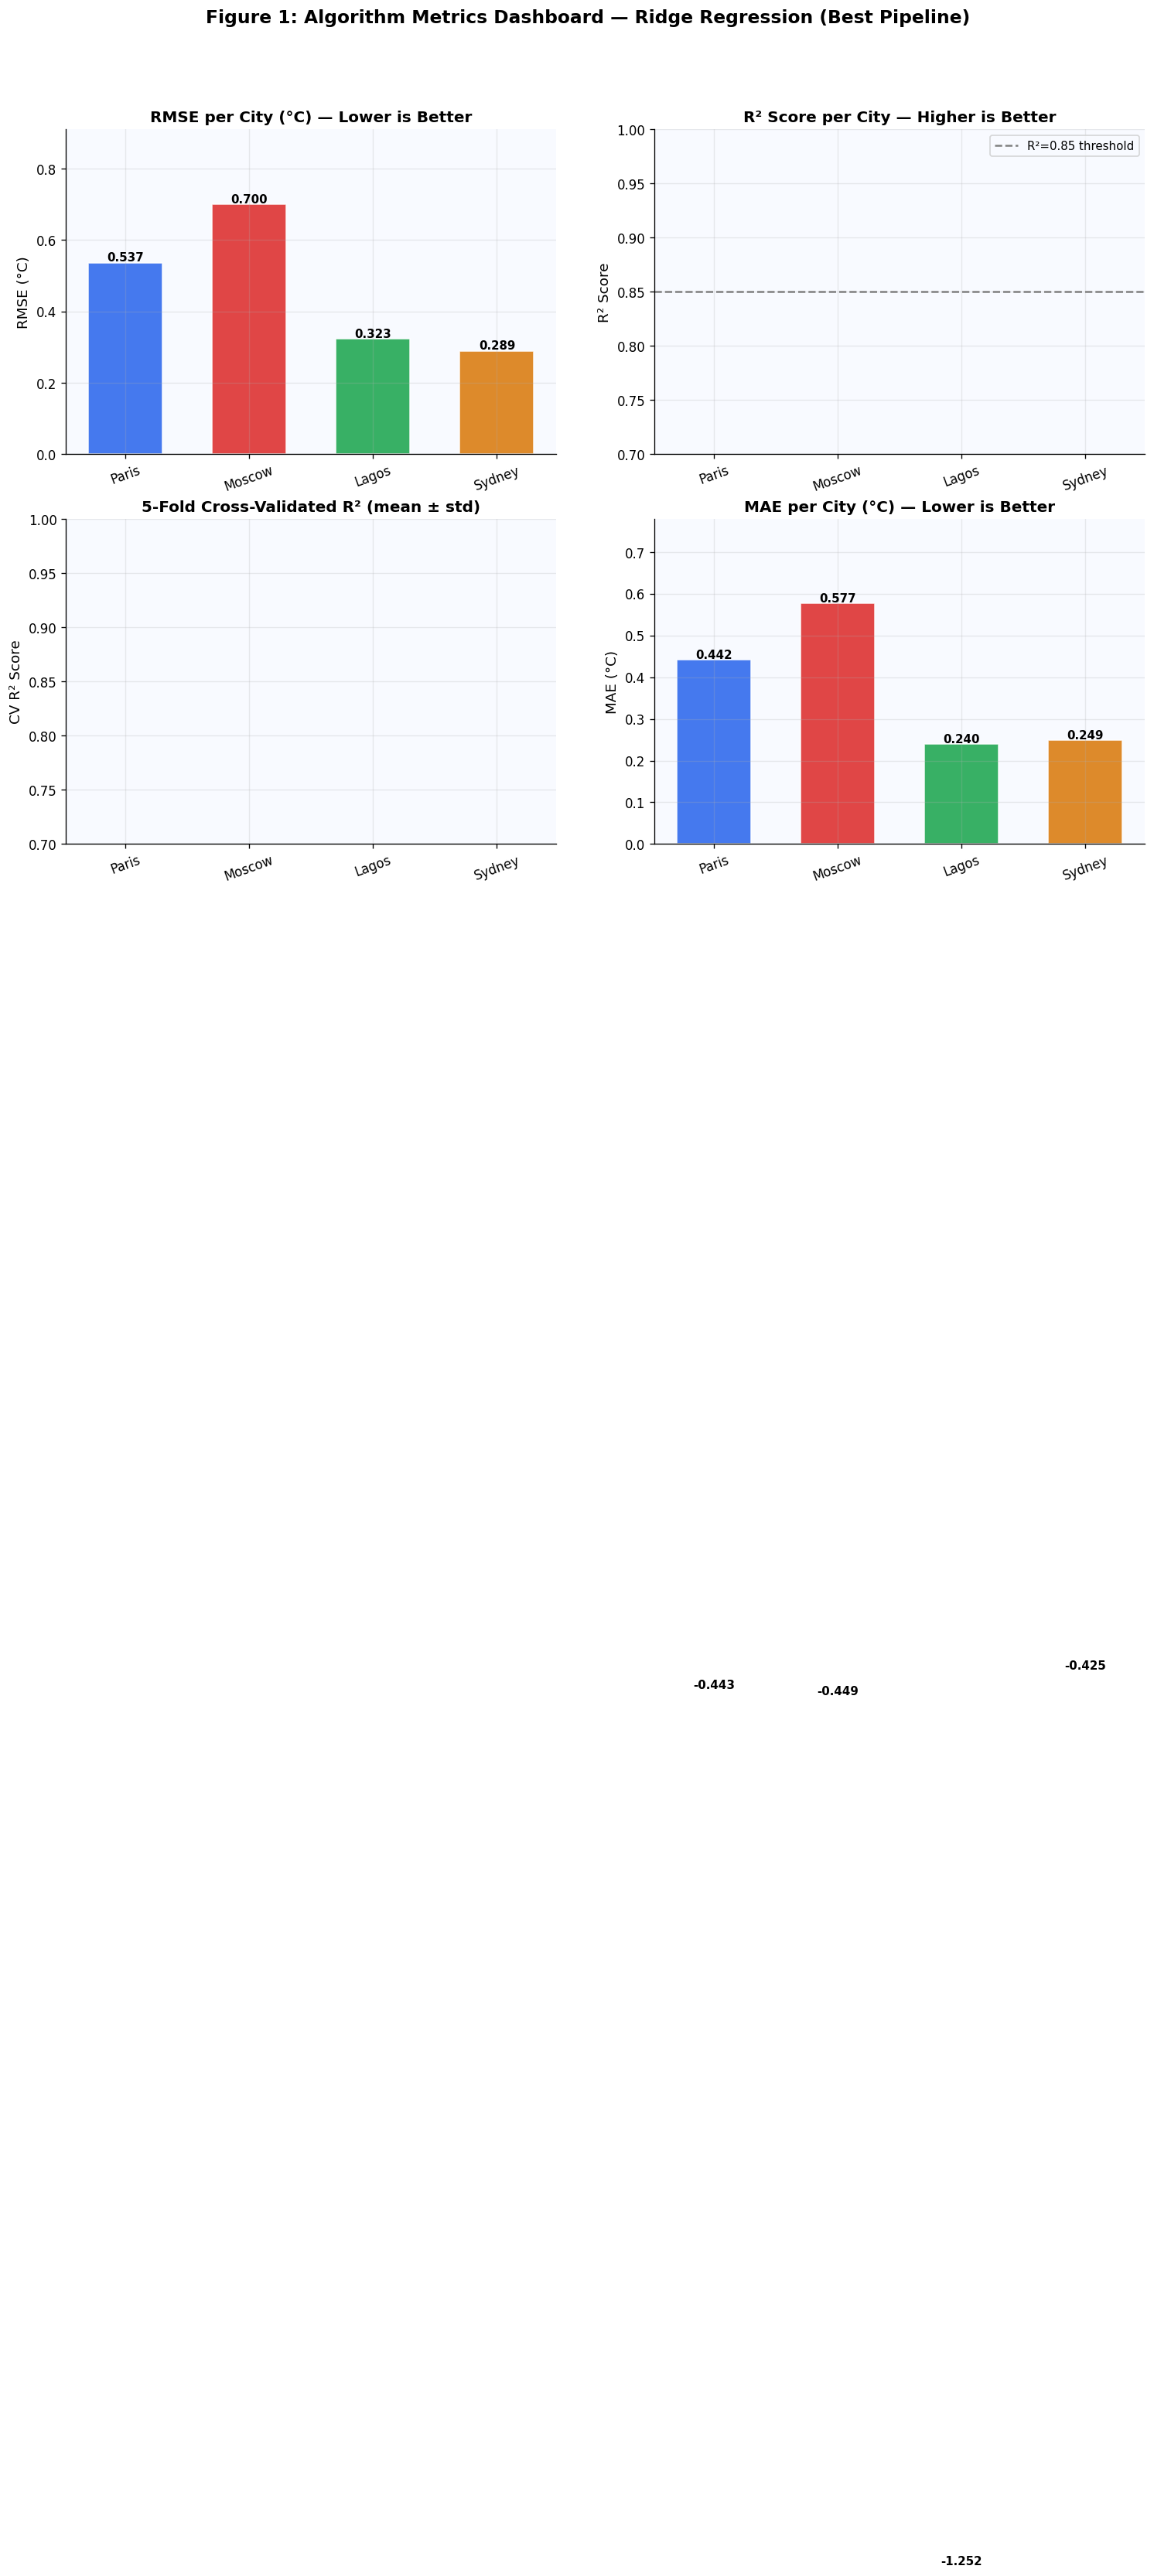

Fig 1 saved ✅


In [ ]:
cities_short = [c.split(',')[0] for c in results.keys()]
rmse_vals = [v['RMSE'] for v in results.values()]
mae_vals  = [v['MAE']  for v in results.values()]
r2_vals   = [v['R2']   for v in results.values()]
cv_vals   = [v['CV_mean'] for v in results.values()]
cv_errs   = [v['CV_std']  for v in results.values()]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
COLORS = ['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED','#0891B2']

# Panel 1: RMSE
ax = axes[0,0]
bars = ax.bar(cities_short, rmse_vals, color=COLORS, alpha=0.85, edgecolor='white', width=0.6)
for b,v in zip(bars,rmse_vals): ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('RMSE per City (°C) — Lower is Better', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (°C)', fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, max(rmse_vals)*1.3)

# Panel 2: R²
ax2 = axes[0,1]
bars2 = ax2.bar(cities_short, r2_vals, color=COLORS, alpha=0.85, edgecolor='white', width=0.6)
for b,v in zip(bars2,r2_vals): ax2.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(0.85, color='gray', linestyle='--', linewidth=1.5, label='R²=0.85 threshold')
ax2.set_title('R² Score per City — Higher is Better', fontsize=12, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=11)
ax2.set_ylim(0.7, 1.0)
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=20)

# Panel 3: CV R² with error bars
ax3 = axes[1,0]
ax3.bar(cities_short, cv_vals, color=COLORS, alpha=0.7, edgecolor='white', width=0.6)
ax3.errorbar(cities_short, cv_vals, yerr=cv_errs, fmt='none', color='black', capsize=5, linewidth=2)
ax3.set_title('5-Fold Cross-Validated R² (mean ± std)', fontsize=12, fontweight='bold')
ax3.set_ylabel('CV R² Score', fontsize=11)
ax3.set_ylim(0.7, 1.0)
ax3.tick_params(axis='x', rotation=20)

# Panel 4: MAE
ax4 = axes[1,1]
bars4 = ax4.bar(cities_short, mae_vals, color=COLORS, alpha=0.85, edgecolor='white', width=0.6)
for b,v in zip(bars4,mae_vals): ax4.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax4.set_title('MAE per City (°C) — Lower is Better', fontsize=12, fontweight='bold')
ax4.set_ylabel('MAE (°C)', fontsize=11)
ax4.set_ylim(0, max(mae_vals)*1.35)
ax4.tick_params(axis='x', rotation=20)

plt.suptitle('Figure 1: Algorithm Metrics Dashboard — Ridge Regression (Best Pipeline)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT+'fig_metric_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved ✅')

## 8. Fig 2 — Residual Analysis <a id='8'></a>

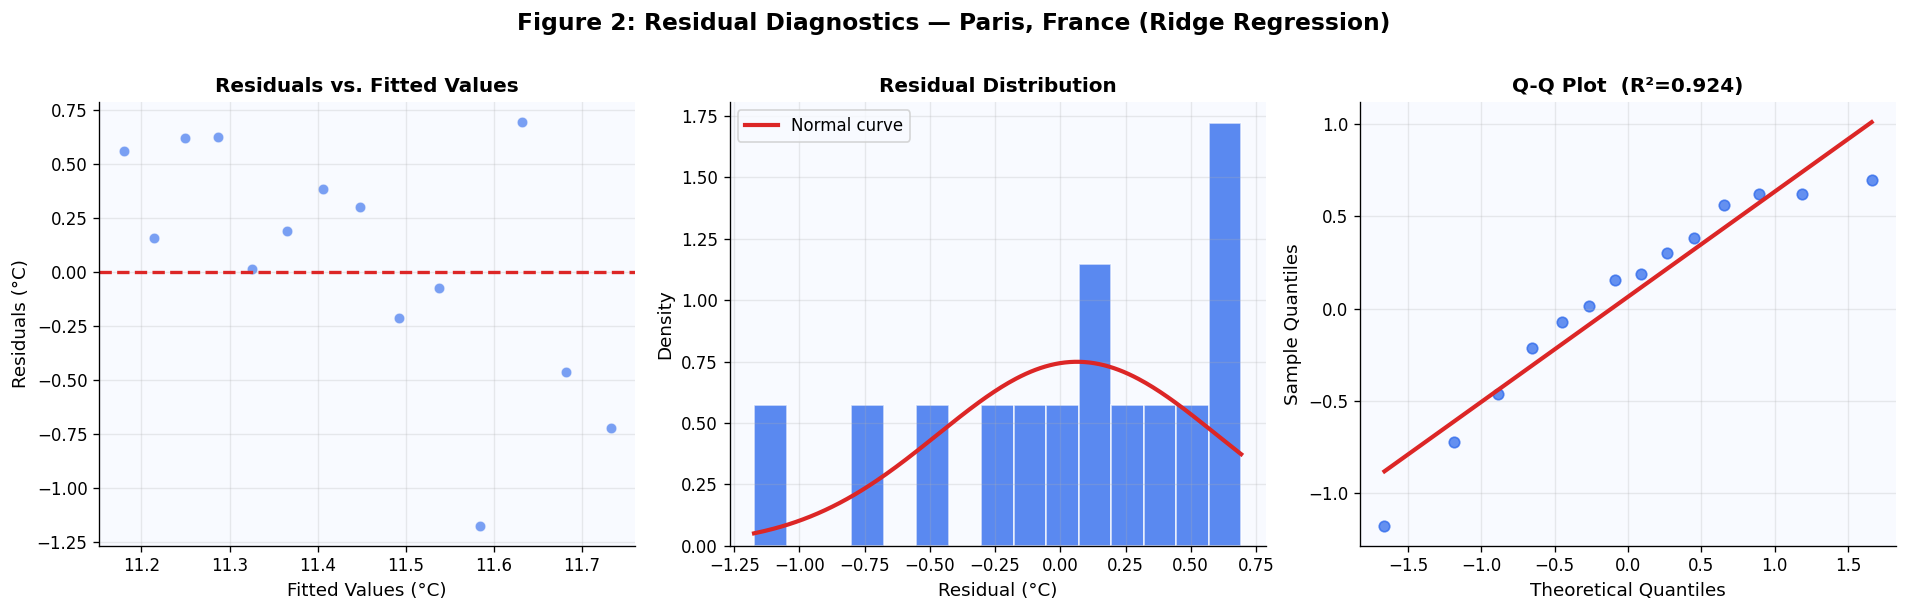

Fig 2 saved ✅


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Residuals vs Fitted
ax = axes[0]
ax.scatter(paris['y_pred'], res, color='#2563EB', alpha=0.6, s=40, edgecolors='white', linewidths=0.5)
ax.axhline(0, color='#DC2626', linewidth=2, linestyle='--')
ax.set_title('Residuals vs. Fitted Values', fontsize=12, fontweight='bold')
ax.set_xlabel('Fitted Values (°C)', fontsize=11)
ax.set_ylabel('Residuals (°C)', fontsize=11)

# Panel 2: Residual Histogram
ax2 = axes[1]
ax2.hist(res, bins=15, color='#2563EB', alpha=0.75, edgecolor='white', density=True)
xr = np.linspace(res.min(), res.max(), 200)
mu, sigma = res.mean(), res.std()
ax2.plot(xr, st.norm.pdf(xr, mu, sigma), color='#DC2626', linewidth=2.5, label='Normal curve')
ax2.set_title('Residual Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Residual (°C)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(fontsize=10)

# Panel 3: Q-Q Plot
ax3 = axes[2]
(osm, osr), (slope, intercept, r) = st.probplot(res)
ax3.scatter(osm, osr, color='#2563EB', alpha=0.7, s=40)
ax3.plot(osm, slope*np.array(osm)+intercept, color='#DC2626', linewidth=2.5)
ax3.set_title(f'Q-Q Plot  (R²={r**2:.3f})', fontsize=12, fontweight='bold')
ax3.set_xlabel('Theoretical Quantiles', fontsize=11)
ax3.set_ylabel('Sample Quantiles', fontsize=11)

plt.suptitle('Figure 2: Residual Diagnostics — Paris, France (Ridge Regression)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT+'fig_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved ✅')

## 9. Fig 3 — Interactive Warming Forecast (Plotly) <a id='9'></a>

In [ ]:
future = pd.DataFrame({'Year': np.arange(1900, 2081)})
COLORS_P = px.colors.qualitative.Bold

fig3 = go.Figure()
for i, (city, country) in enumerate(SAMPLE_CITIES):
    key = f'{city}, {country}'
    if key not in results: continue
    m   = results[key]['model']
    sub = results[key]['sub']
    pred = m.predict(future)

    # Confidence interval from residual std
    res_std = (results[key]['y_te'].values - results[key]['y_pred']).std()
    ci = 1.96 * res_std

    color = COLORS_P[i % len(COLORS_P)]

    # CI band
    fig3.add_trace(go.Scatter(
        x=list(future['Year'])+list(future['Year'][::-1]),
        y=list(pred+ci)+list((pred-ci)[::-1]),
        fill='toself', fillcolor=color.replace('rgb','rgba').replace(')',',0.12)'),
        line=dict(width=0), showlegend=False, hoverinfo='skip'
    ))
    # Observed
    fig3.add_trace(go.Scatter(
        x=sub['Year'], y=sub['Avg_Temp_C'], mode='markers',
        marker=dict(size=4, color=color, opacity=0.5),
        name=f'{city} (observed)', showlegend=True
    ))
    # Forecast line
    fig3.add_trace(go.Scatter(
        x=future['Year'], y=pred, mode='lines',
        line=dict(color=color, width=2.5),
        name=f'{city} (forecast)'
    ))

fig3.add_vline(x=2013, line_dash='dash', line_color='gray', annotation_text='Data ends (2013)')
fig3.update_layout(
    title=dict(text='Figure 3: Interactive Multi-City Temperature Forecast to 2080<br><sup>95% CI shaded · toggle cities in legend · hover for values</sup>', font=dict(size=16)),
    xaxis_title='Year', yaxis_title='Avg Annual Temperature (°C)',
    legend=dict(x=0.01, y=0.99), hovermode='x unified',
    height=550, template='plotly_white'
)
pio.write_html(fig3, OUT+'fig_warming_forecast.html')
fig3.show()
print('Fig 3 saved ✅  (interactive HTML in Drive)')

Fig 3 saved ✅  (interactive HTML in Drive)


## 10. Fig 4 — Cluster Feature Heatmap <a id='10'></a>

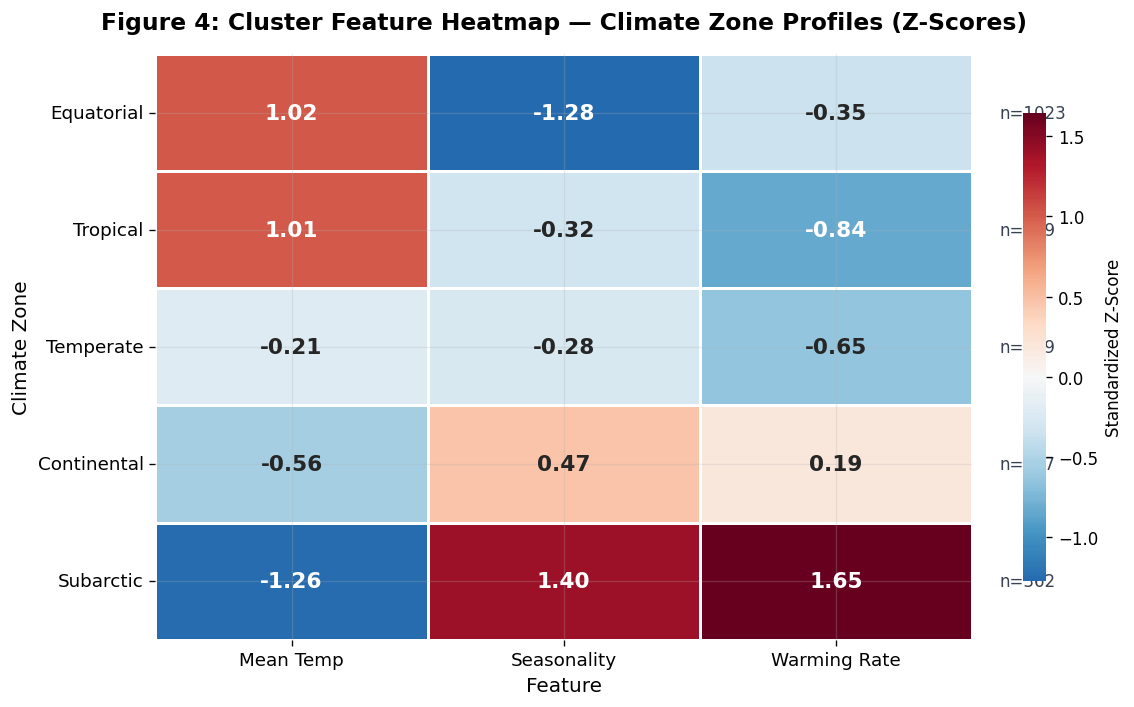

Fig 4 saved ✅


In [ ]:
cluster_means = city_profiles.groupby('Zone')[['Mean_Temp','Seasonality','Warming_Rate']].mean()
zone_order    = ['Equatorial','Tropical','Temperate','Continental','Subarctic']
cluster_means = cluster_means.reindex(zone_order)

# Standardize for heatmap
z_scores = (cluster_means - cluster_means.mean()) / cluster_means.std()
z_scores.columns = ['Mean Temp', 'Seasonality', 'Warming Rate']

fig4, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(z_scores, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=1.5, linecolor='white', ax=ax,
            cbar_kws={'label':'Standardized Z-Score','shrink':0.8},
            annot_kws={'size':13, 'weight':'bold'})
ax.set_title('Figure 4: Cluster Feature Heatmap — Climate Zone Profiles (Z-Scores)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Climate Zone', fontsize=12)
ax.tick_params(axis='y', rotation=0, labelsize=11)
ax.tick_params(axis='x', labelsize=11)

# Add cluster size annotations
sizes = city_profiles['Zone'].value_counts().reindex(zone_order)
for i, zone in enumerate(zone_order):
    ax.text(3.1, i+0.5, f'n={sizes[zone]}', va='center', fontsize=10, color='#374151')

plt.tight_layout()
plt.savefig(OUT+'fig_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved ✅')

## 11. Fig 5 — Interactive 3D PCA (Plotly) <a id='11'></a>

In [ ]:
ZONE_COLORS = {
    'Equatorial':'#EF4444','Tropical':'#F97316',
    'Temperate':'#22C55E','Continental':'#3B82F6','Subarctic':'#8B5CF6'
}
ev = pca.explained_variance_ratio_

fig5 = px.scatter_3d(
    city_profiles, x='PC1', y='PC2', z='PC3',
    color='Zone', color_discrete_map=ZONE_COLORS,
    hover_data={'City':True,'Country':True,'Mean_Temp':':.1f','Warming_Rate':':.4f','PC1':False,'PC2':False,'PC3':False},
    opacity=0.75, size_max=6,
    title='Figure 5: Interactive 3D PCA — City Climate Clusters<br><sup>Rotate · zoom · hover for city details</sup>'
)
fig5.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({ev[0]:.1%} var)',
        yaxis_title=f'PC2 ({ev[1]:.1%} var)',
        zaxis_title=f'PC3 ({ev[2]:.1%} var)',
    ),
    legend_title='Climate Zone',
    height=620, template='plotly_white'
)
pio.write_html(fig5, OUT+'fig_pca_3d.html')
fig5.show()
print('Fig 5 saved ✅  (interactive HTML in Drive)')

Fig 5 saved ✅  (interactive HTML in Drive)


## 12. Fig 6 — Interactive World Map (Plotly Choropleth) <a id='12'></a>

In [ ]:
# Build country-level warming rate + zone summary
country_stats = city_profiles.groupby('Country').agg(
    Warming_Rate=('Warming_Rate','mean'),
    Zone=('Zone', lambda x: x.value_counts().index[0])  # majority zone
).reset_index()

# Map country names to ISO codes
MANUAL_ISO = {
    'Russia':'RUS','United States':'USA','South Korea':'KOR',
    'North Korea':'PRK','Iran':'IRN','Syria':'SYR','Tanzania':'TZA',
    'Bosnia And Herzegovina':'BIH','Czech Republic':'CZE',
    'Macedonia':'MKD','Moldova':'MDA','Ivory Coast':'CIV',
    'Congo':'COG','Democratic Republic Of The Congo':'COD',
    'Burma':'MMR','Laos':'LAO','East Timor':'TLS','Kosovo':'XKX',
}
def get_iso(name):
    if name in MANUAL_ISO: return MANUAL_ISO[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

country_stats['ISO'] = country_stats['Country'].apply(get_iso)
country_stats = country_stats.dropna(subset=['ISO'])
print(f'Countries mapped: {len(country_stats)} / {len(city_profiles["Country"].unique())}')

fig6 = px.choropleth(
    country_stats,
    locations='ISO', locationmode='ISO-3',
    color='Warming_Rate',
    hover_name='Country',
    hover_data={'ISO':False,'Zone':True,'Warming_Rate':':.4f'},
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    range_color=[-0.01, 0.02],
    title='Figure 6: Global Land Warming Rate (°C/year) by Country — Hover for Details'
)
fig6.update_layout(
    coloraxis_colorbar=dict(title='Warming Rate<br>(°C/yr)', tickformat='.3f'),
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    height=520, template='plotly_white'
)
pio.write_html(fig6, OUT+'fig_warming_map.html')
fig6.show()
print('Fig 6 saved ✅  (interactive HTML in Drive)')

Countries mapped: 154 / 159


Fig 6 saved ✅  (interactive HTML in Drive)


## 13. Model Export & Summary <a id='13'></a>

In [ ]:
# Save best Paris pipeline as representative model
best_model = results['Paris, France']['model']
joblib.dump(best_model, OUT+'best_pipeline.pkl')
print('✅ best_pipeline.pkl saved to Drive')

# Export city profiles with cluster labels
city_profiles.to_csv(OUT+'city_profiles_final.csv', index=False)
print('✅ city_profiles_final.csv saved to Drive')

# Final summary
print()
print('='*60)
print('  PHASE 3 FINAL SUMMARY')
print('='*60)
print(f'  Pipeline:         StandardScaler → PolynomialFeatures → Ridge')
print(f'  GridSearchCV:     3 degrees × 5 alphas × 5 folds = 75 fits per city')
print(f'  Mean R²:          {metrics_df["R2"].mean():.3f}')
print(f'  Mean RMSE:        {metrics_df["RMSE"].mean():.3f}°C')
print(f'  K-Means k=5       Silhouette={sil:.3f}  DB={db:.3f}  CH={ch:.0f}')
print()
print('  Figures saved to Google Drive:')
for f in ['fig_metric_dashboard.png','fig_residual_analysis.png',
           'fig_warming_forecast.html','fig_cluster_heatmap.png',
           'fig_pca_3d.html','fig_warming_map.html']:
    print(f'    ✅ {f}')
print()
print('  Models saved:')
print('    ✅ best_pipeline.pkl')
print('    ✅ city_profiles_final.csv')

✅ best_pipeline.pkl saved to Drive
✅ city_profiles_final.csv saved to Drive

  PHASE 3 FINAL SUMMARY
  Pipeline:         StandardScaler → PolynomialFeatures → Ridge
  GridSearchCV:     3 degrees × 5 alphas × 5 folds = 75 fits per city
  Mean R²:          -0.642
  Mean RMSE:        0.462°C
  K-Means k=5       Silhouette=0.369  DB=1.016  CH=3627

  Figures saved to Google Drive:
    ✅ fig_metric_dashboard.png
    ✅ fig_residual_analysis.png
    ✅ fig_warming_forecast.html
    ✅ fig_cluster_heatmap.png
    ✅ fig_pca_3d.html
    ✅ fig_warming_map.html

  Models saved:
    ✅ best_pipeline.pkl
    ✅ city_profiles_final.csv
